# Mount drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q cvzone

In [3]:
!pip install ultralytics==8.2.103 -q

# Import libraries

In [4]:
import cv2 as cv
from ultralytics import YOLO
import math
import numpy as np
from google.colab.patches import cv2_imshow
import os
import matplotlib.pyplot as plt

# Testing the reloaded model

In [12]:
# =========================
# Paths
# =========================
output_folder = "/content/drive/MyDrive/"
os.makedirs(output_folder, exist_ok=True)
output_video_path = os.path.join(output_folder, "output.mp4")

# =========================
# Load YOLO Models
# =========================
model = YOLO("yolov8s.pt")
correct_cap_model = YOLO('/content/drive/MyDrive/dataset/Ramak/models/bottle-cap-v8/weights/best.pt')

class_names = {0: 'defect', 1: 'good', 2: 'loos-cap', 3: 'no-cap', 4: 'ring-missing'}

# =========================
# Functions
# =========================
def upscale_image(img, scale=2):
    return cv.resize(img, (img.shape[1]*scale, img.shape[0]*scale), interpolation=cv.INTER_CUBIC)

def predict_cap_class(cap_crop):
    """Crop → upscale → run cap classifier → return class name"""
    if cap_crop is None or cap_crop.size == 0:
        return None

    cap_up = upscale_image(cap_crop, scale=3)
    results = correct_cap_model.predict(source=cap_up, conf=0.8, verbose=False)

    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None

    cls_id = int(boxes[0].cls[0])
    return class_names.get(cls_id, None)

def predict_cap_from_path(img_path):
    if not os.path.exists(img_path):
        return None
    img = cv.imread(img_path)
    return predict_cap_class(img)

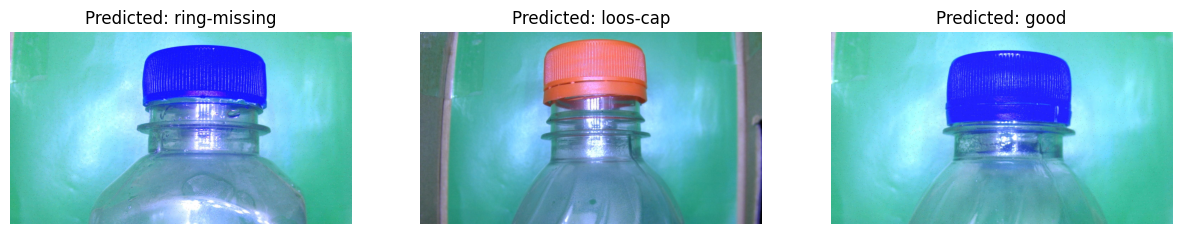

In [13]:
# Your image paths
img_paths = [
    '/content/drive/MyDrive/dataset/Ramak/yolov8_cap_dataset/train/images/110_jpg.rf.2f32764687b16a8b891d14d20a9b37ff.jpg',
    '/content/drive/MyDrive/dataset/Ramak/yolov8_cap_dataset/train/images/108_jpg.rf.5de0233a682f4eb71c1ffd1c9a59b512.jpg',
    '/content/drive/MyDrive/dataset/Ramak/yolov8_cap_dataset/train/images/11_jpg.rf.3f268dd7211f3d1995c4ca734d8ece35.jpg'
]

# Plot images with predictions
plt.figure(figsize=(15,5))
for i, img_path in enumerate(img_paths):
    img = cv.imread(img_path)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    label = predict_cap_from_path(img_path)
    plt.subplot(1, 3, i+1)
    plt.imshow(img_rgb)
    plt.title(f'Predicted: {label}')
    plt.axis('off')

plt.show()

# Apply the finetuned YOLO model on a video

In [14]:
# Silence YOLO's noisy prints
os.environ["YOLO_VERBOSE"] = "False"
import logging
logging.getLogger("ultralytics").setLevel(logging.WARNING)

print("Setup complete – all personal paths are now hidden")

Setup complete – all personal paths are now hidden


In [ ]:
import cv2 as cv
import numpy as np
import os
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# =========================
# Video Loading
# =========================
cap = cv.VideoCapture('/content/drive/MyDrive/dataset/bottle.mp4')

frame_width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv.CAP_PROP_FPS)

# Output video writer
out = cv.VideoWriter(output_video_path, cv.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

classnames = model.model.names
line_x = int(frame_width * 0.5)
line = [line_x, 0, line_x, frame_height]

# =========================
# Tracking and Counters
# =========================
frame_index = 0
frame_interval = 30
counterin = []
closed_caps = []
previous_positions = {}
bottle_speeds = {}
counted_ids = {}

cap_color_map = {
    "good": (0, 255, 0),
    "loos-cap": (0, 255, 255),
    "no-cap": (0, 0, 255),
    "defect": (0, 140, 255),
    "ring-missing": (255, 0, 255)
}

# =========================
# Run Bottle Tracking
# =========================
results = model.track(
    source='/content/drive/MyDrive/dataset/bottle.mp4',
    stream=True,
    persist=True,
    tracker="bytetrack.yaml",
    classes=[classnames.index('bottle')] if 'bottle' in classnames else None,
    conf=0.6,
    imgsz=960
)

for r in results:
    img = r.orig_img.copy()
    img_for_crop = img.copy()
    frame_index += 1

    cv.line(img, (line[0], line[1]), (line[2], line[3]), (0, 255, 255), 4)

    boxes = r.boxes
    if boxes is not None:
        for box in boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            track_id = int(box.id[0]) if box.id is not None else -1

            if classnames[cls_id] == "bottle" and conf >= 0.5:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                w = x2 - x1
                h = y2 - y1
                cx = x1 + w // 2
                cy = y1 + h // 2

                cv.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

                # Speed estimation
                PIXELS_PER_CM = 37.8 #  must be callibrated based on the distances

                if track_id in previous_positions:
                    prev_cx, _ = previous_positions[track_id]
                    pixel_distance = cx - prev_cx
                    cm_distance = pixel_distance / PIXELS_PER_CM
                    speed_cm_per_sec = cm_distance * fps
                    bottle_speeds[track_id] = speed_cm_per_sec
                else:
                    bottle_speeds[track_id] = 0.0

                previous_positions[track_id] = (cx, cy)

                # Display ID and speed
                cv.putText(img, f"ID:{track_id}", (x1, y1 - 20),
                           cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
                cv.putText(img, f"S:{bottle_speeds[track_id]:.1f}", (x1, y1 - 5),
                           cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

                # Define cap crop region (top 20%)
                cap_y2 = y1 + int((y2 - y1) * 0.20)
                cap_crop = img_for_crop[y1:cap_y2, x1:x2]

                # Count when passing line
                if (line[0] - 10) < cx < (line[0] + 10) and track_id not in counted_ids:
                    counted_ids[track_id] = True
                    counterin.append(track_id)

                    # Predict cap class
                    cap_class = predict_cap_class(cap_crop)
                    if cap_class:
                        closed_caps.append(track_id)
                        color = cap_color_map.get(cap_class, (255, 255, 255))
                        cv.putText(img, cap_class, (x1, y2 + 20),
                                   cv.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # Summary overlay
    cv.putText(img, f'Total Bottles = {len(counterin)}',
               (50, 50), cv.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

    cv.putText(img, f'Closed Cap = {len(closed_caps)}',
               (50, 100), cv.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 3)

    # Show every frame_interval
    if frame_index % frame_interval == 0:
        resized = cv.resize(img, (960, 540))
        # cv2_imshow(resized)

    out.write(img)

cap.release()
out.release()
print(f"✅ Output saved to: {output_video_path}")


✅ Output saved to: /content/drive/MyDrive/output.mp4
